In [ ]:
import sys
import os

# change the path to your own path
sys.path.append("/Users/wangweixiang/Downloads/Link_Prediction_metric_consider_structure_result 2")

# change the path to your own path
os.chdir("/Users/wangweixiang/Downloads/Link_Prediction_metric_consider_structure_result 2")


from utils.parameter_parser import parameter_parser
from utils.utils import tab_printer, read_data, walk_exist
from utils.eval import (
    get_accuracy_scores,
    get_modularity,
    get_information_unfairness,
    get_Gini_coefficient
)

from algs.proximity_base import (
    jaccard,
    adamic_adar,
    preferential_attachment
)

from algs.greedy import greedy_wrapper
from skipGram.walk_generator import walk_generator
from algs.flip import DW_GAN_LP
from utils.logger import Logger
from algs.mab import MAB_LP

from tqdm import tqdm
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from numpy import trapz

import csv

import networkx as nx

from stratified_disparity import StratifiedDisparity


%config InlineBackend.figure_format = 'svg'

In [2]:
args = parameter_parser()

# change the data name
args.file_name = "bowdoin.pk"

tab_printer(args)

data = read_data(args)

G = data['G']

# ---------------------------------------------------------
# Create copy of graph with protected attribute labels
# ---------------------------------------------------------
# communities contains the ground-truth group membership
# for each node in the dataset
#
# Example:
# community 0 -> nodes with attribute 0
# community 1 -> nodes with attribute 1
# ---------------------------------------------------------
G_original = data['G'].copy()

communities = data['communities']

for i in range(len(communities)):
    for node in communities[i]:
        G_original.nodes[node]['att'] = i


# Build positive edges G (oracle) based on data['examples']
G_oracle = G.copy()

positive_edges = [
    [e[0], e[1]]
    for e in data['examples']
    if e[2] == 1
]

G_oracle.add_edges_from(positive_edges)


print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

+-----------------+----------------+
|    Parameter    |     Value      |
+=================+================+
| Algorithm       | jac            |
+-----------------+----------------+
| Batch size      | 32             |
+-----------------+----------------+
| Beta d          | 0.100          |
+-----------------+----------------+
| Beta g          | 0.900          |
+-----------------+----------------+
| Beta l          | 0.200          |
+-----------------+----------------+
| Change percent  | 0.030          |
+-----------------+----------------+
| Cuda            | 0              |
+-----------------+----------------+
| Dimensions      | 128            |
+-----------------+----------------+
| Embedding path  | ./data/embds/  |
+-----------------+----------------+
| Epochs          | 3              |
+-----------------+----------------+
| File            | None           |
+-----------------+----------------+
| File name       | bowdoin.pk     |
+-----------------+----------------+
|

In [3]:
edge_accuracy_list = []
edge_type_list = []
all_recommended_edges = []


for n in G.nodes:

    # candidate edges = all non-existing 2-hop edges
    candidate_nodes = []

    for neighbor in list(G.adj[n]):
        candidate_nodes += [
            i_
            for i_ in G.adj[neighbor]
            if i_ != n
        ]


    # avoid adding duplicate edges
    candidate_edges = set()

    for cn in candidate_nodes:
        if cn not in G.adj[n]:
            candidate_edges.add((n, cn))


    candidate_edges_array = []

    for item in candidate_edges:
        candidate_edges_array.append(
            [item[0], item[1], 0]
        )

    candidate_edges_array = np.array(candidate_edges_array)


    # no possible recommendations
    if len(candidate_edges_array) == 0:
        continue


    # Jaccard prediction score
    y_pred = jaccard(
        G,
        candidate_edges_array
    )


    score = []

    for i, x in enumerate(y_pred):
        score.append(
            [
                candidate_edges_array[i][0],
                candidate_edges_array[i][1],
                x
            ]
        )


    # highest scores first
    score.sort(
        key=lambda x: x[2],
        reverse=True
    )


    # recommend top 10 edges
    number_predict = min(
        10,
        len(score)
    )


    for i in range(number_predict):

        u, v, _ = score[i]

        all_recommended_edges.append(score[i])


        # whether recommended edge exists in oracle
        edge_is_correct = int(
            v in G_oracle.adj[u]
        )

        edge_accuracy_list.append(
            edge_is_correct
        )


        # intra/inter community label
        edge_type = (
            "intra"
            if G_original.nodes[u]["att"] ==
               G_original.nodes[v]["att"]
            else
               "inter"
        )

        edge_type_list.append(edge_type)



print("Recommended edges:", len(all_recommended_edges))
print("Correctness labels:", len(edge_accuracy_list))
print("Edge groups:", len(edge_type_list))

Recommended edges: 22460
Correctness labels: 22460
Edge groups: 22460


In [4]:
edge_ids = list(range(len(all_recommended_edges)))


edge_group_labels = {
    edge_idx: 0
    if edge_type_list[edge_idx] == "intra"
    else 1
    for edge_idx in edge_ids
}



def bin_by_edge_degree(G, edge_ids):

    features = []

    for edge_idx in edge_ids:

        u, v, _ = all_recommended_edges[edge_idx]

        features.append(
            abs(G.degree(u) - G.degree(v))
        )

    return features



def std(acc):
    return np.std(acc, ddof=1)



SD_edges = StratifiedDisparity(
    G_original,
    edge_ids,
    bin_by_edge_degree,
    std,
    log=False,
    data_log=False
)

<AxesSubplot:title={'center':'Stratified Disparity Curve'}, xlabel='Number of bins', ylabel='Stratified Disparity'>

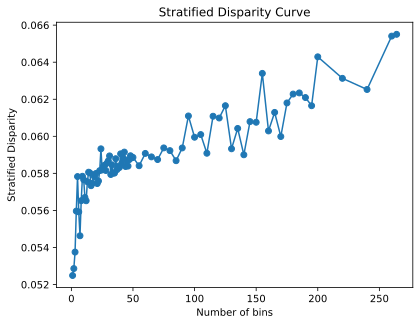

In [5]:
# Compute disparity across bins of edge-degree difference

curve_edges_deg = SD_edges.compute_curve(
    edge_accuracy_list,
    edge_group_labels
)


SD_edges.plot_curve(
    curve_edges_deg
)

<AxesSubplot:xlabel='Structure bin', ylabel='Average performance'>

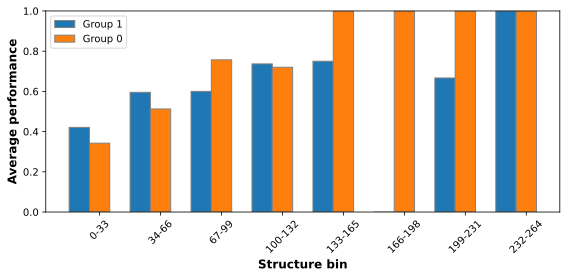

In [6]:
# Compare average link prediction performance
# between intra/inter edges within each structural bin

SD_edges.plot_bin_group_performance(
    acc_list=edge_accuracy_list,
    group_labels=edge_group_labels,
    num_bin=8
)

<AxesSubplot:title={'center':'Stratified Disparity Curve'}, xlabel='Number of bins', ylabel='Stratified Disparity'>

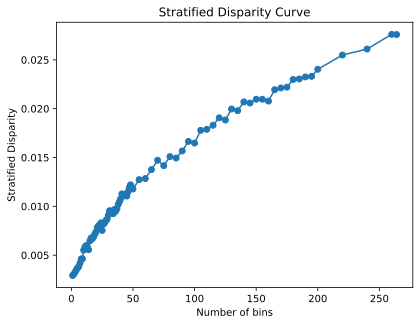

In [7]:
# Generate random baseline by shuffling group labels
baseline_edges = SD_edges.permutation_baseline(
    acc_list=edge_accuracy_list,
    group_labels=edge_group_labels,
    n_perm=20,
    random_state=42
)


SD_edges.plot_curve(
    baseline_edges
)

{'num_bins': 140.0, 'stratified_disparity': 0.038308844482251504}


<AxesSubplot:title={'center':'Stratified Disparity Curve'}, xlabel='Number of bins', ylabel='Stratified Disparity'>

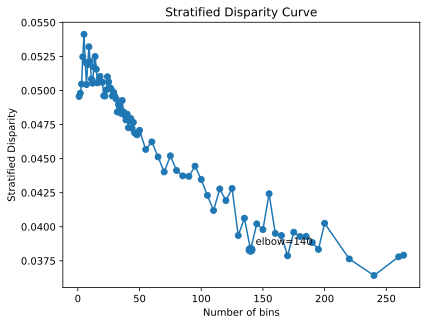

In [8]:
# Subtract random expected disparity
denoised_curve = curve_edges_deg.copy()

denoised_curve["stratified_disparity"] = (
    denoised_curve["stratified_disparity"]
    - baseline_edges["stratified_disparity"]
)

# Find point where adding more bins gives diminishing returns (elbow point)
elbow = SD_edges.find_elbow(
    denoised_curve
)

print(elbow)

# Plot final noise-adjusted disparity curve
SD_edges.plot_curve(
    denoised_curve,
    elbow=elbow
)